In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import plotly.graph_objects as go

import os
# from pyfmreaderpsnex.ps_nex.loadMaps import checkMapFileNULL, remove_nan_and_get_indices, load_map_file_csv, compute_time_difference
# from pyfmreaderpsnex.ps_nex.parseTDMS import get_channel_names, parse_tdms, grab_tdms
# from pyfmreaderpsnex.plotting import smooth_derivative
# import plotly.io as pio
# import seaborn as sns
# import sys

from pyfmreader import loadfile
from pyfmreader.ps_nex.parseTDMS import grab_tdms
from pyfmrheo.utils.force_curves import correct_tilt
from scipy.stats import linregress

pi = math.pi
 

In [2]:
from scipy.signal import savgol_filter

# scan from left to right, corrected deflection, and check when value becomes positive
def find_first_positive(arr):
    """
    Returns an array of first positives in a NumPy array.
    Returns None if no positive value is found.
    """
    arr = np.asarray(arr)
    positives = np.where(arr > 0)[0]
    return positives if positives.size > 0 else None

def savitzky_golay_smooth(y, window_length=11, polyorder=3):
    """
    Applies Savitzky-Golay smoothing to a 1D array.

    Parameters:
    - y: array-like, the signal to smooth
    - window_length: int, length of the filter window (must be odd and >= polyorder+2)
    - polyorder: int, order of the polynomial used to fit the samples

    Returns:
    - smoothed_y: numpy array, the smoothed signal
    # """
    y = np.asarray(y)
    # Ensure window_length is odd and less than or equal to the size of y
    if window_length % 2 == 0:
        window_length += 1
    if window_length > len(y):
        window_length = len(y) if len(y) % 2 == 1 else len(y) - 1
    return savgol_filter(y, window_length=window_length, polyorder=polyorder)



### Read file and parse necessary data

In [3]:
# file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/03/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.31.15.19.tdms'
directory = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/600/'

show_plots = False

first_file, all_files = grab_tdms(directory)

print(f'number of tdms files found: {len(all_files)}')

number of tdms files found: 100


In [4]:
# Load File
filename = all_files[31] #or 31, 29
filename = '/Users/evillz/Data/article/2025_07_01_THP1_phd/error_files_test/1000_3/error_file/fcurve_thp1_cell1_ret_1000ums__2025.07.01_17.02.53.84.tdms'
file = loadfile(filename)
filemetadata = file.filemetadata
print(filemetadata['file_type'])
print(f'analyzing file: {filename}')

segment_0_ramp_speed_um/s: 20 um/s
segment_1_ramp_speed_um/s: 0 um/s
segment_2_ramp_speed_um/s: 100 um/s
PSNEX.tdms
analyzing file: /Users/evillz/Data/article/2025_07_01_THP1_phd/error_files_test/1000_3/error_file/fcurve_thp1_cell1_ret_1000ums__2025.07.01_17.02.53.84.tdms


In [5]:
# Filemetadata
file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
K = filemetadata['spring_const_Nbym'] #N/m
height_channel_key = filemetadata['height_channel_key']
deflection_channel_key = filemetadata['deflection_chanel_key']

defl_sens = file_deflection_sensitivity / 1e9 #m/V

print(f"Height channel: {height_channel_key}")
print(f"Deflection Sens.: {defl_sens} m/V")
print(f"spring_const_Nbym: {K} N/m")

Height channel: Zpiezo_stage_sensor_(V)
Deflection Sens.: 1.69e-08 m/V
spring_const_Nbym: 0.1 N/m


In [6]:
# Select curve by index
curve_idx = 0
try : 
    force_curve = file.getcurve(curve_idx)
except IndexError:
    print(f"Curve index {curve_idx} does not exist in the file.")
    force_curve = None  

# Preprocess curve to get the segments
try:
    force_curve.preprocess_force_curve(defl_sens, height_channel_key)
except Exception as e:
    print(f"Error occurred during preprocessing: {e}")


decimation: [1 1 1]
z_sensor_delay: 0, bool_correct_overshoot: False 
points removed : 0
Deflection Length: 447575, Height: 447575
0 481218
segment relative position: 481218, segment duration: 0.9624364999999999
App
removed overshoot
start_indices: [     0 481218 491875]
end_indices: [481218 491875 447575]
NumPnts: [481218  10657  94412]
---------------------
481218 491875
segment relative position: 10657, segment duration: 0.021314299999999998
Con
start_indices: [     0 481218 491875]
end_indices: [481218 491875 447575]
NumPnts: [481218  10657  94412]
---------------------
491875 447575
segment relative position: -44300, segment duration: 0.188825675


ValueError: Number of samples, -44300, must be non-negative.

In [ ]:
# Get segments and indentation
segs = force_curve.get_segments()
# these metadata is only available after getting segments
final_nb_points = filemetadata['final_nb_points']
relative_SR = filemetadata['relative_sr']

# get details of retract segments
for segid, segment in segs:
    if segment.segment_type in ('Retract', 'Ret'):
        # print(f"Segment ID: {segid}, Type: {segment.segment_type}")
        relative_SR_ret = relative_SR[segid]
        vel_ret_um_s = segment.velocity * 1e-03  # Convert nm/s to um/s

# print ('relative_SR:', relative_SR_ret)
# print ('relative_freq(hz):', 1 / relative_SR_ret)
# print (f'vel_ret_um_s: {vel_ret_um_s} um/s')
# indentation = ext_data.indentation

1623, 1623, 1623
Total length of the force curve without contact: 51180
52244 52244


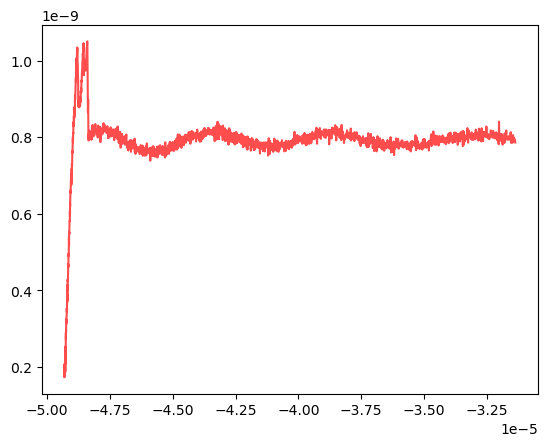

In [ ]:
# Get zheight and vdeflection, for now only get retract
zmin_app = 0
for segid, segment in force_curve.get_segments():
    if segment.segment_type in ('Approach', 'App'):
        zmin_app = segment.zheight.min()
        app_piezo = -segment.zheight
        app_deflection = -segment.vdeflection * K  # Convert to N
        if show_plots:
            plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'g-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.zheight
        ret_deflection = -segment.vdeflection * K  # Convert to N
        time_ret = np.arange(len(ret_piezo)) * relative_SR_ret  # Assuming relative_SR_ret is in Hz, convert to seconds
        print (f"{len(ret_piezo)}, {len(ret_deflection)}, {len(time_ret )}")
        if show_plots:
            plt.plot(segment.zheight - zmin_app, segment.vdeflection, 'r-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Contact', 'Con', 'Pause'):
        con_piezo = -segment.zheight
        con_deflection = -segment.vdeflection * K  # Convert to N
        if show_plots:
            plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'b-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
if show_plots:
    plt.legend()
    plt.xlabel('displacement (m)')
    plt.ylabel('vdeflection (nm)')

# depening if there is a value , get length of total force curve: app+ con + ret
if 'con_piezo' in locals():
    total_length = len(app_piezo) - len(con_piezo) + len(ret_piezo)
print(f"Total length of the force curve without contact: {total_length}")


deflection_N = np.concatenate((app_deflection, ret_deflection))
zheight = np.concatenate((app_piezo, ret_piezo)) 

print (len(zheight), len(deflection_N))

plt.plot(ret_piezo, ret_deflection, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.show()

### Calculate retract Velocity
retract velocity calculated from linnear regression fit, the slope would be the calcualted average velocity

In [ ]:
from scipy.stats import linregress

def calculate_velocity(displacement_um, rel_time):
    """
    Calculate the average velocity from displacement_um and time arrays using linear regression.

    Parameters:
        displacement_um (np.ndarray): Displacement values (in micrometers).
        rel_time (np.ndarray): Time values (in seconds).

    Returns:
        float: Average velocity (slope) in µm/s.
    """
    displacement_um = -displacement_um * 1e6  # Convert to micrometers (for compatibility with previous code)
    # deriv_displacement = np.gradient(displacement_um, rel_time)
    slope, intercept, _, _, _= linregress(rel_time, displacement_um)
    return slope
calculated_velocity = calculate_velocity(-ret_piezo, time_ret)
# print(f'{len(ret_piezo)}, {len(time_ret)}')
print (f"Calculated average velocity: {calculated_velocity:.2f} um/s" )
print(f'metadata_ret_velocity: {vel_ret_um_s:.2f} um/s')

# calculate percent difference from the calculated velocity and the metadata velocity

percent_difference = ((calculated_velocity - vel_ret_um_s) / vel_ret_um_s) *100
print(f"% Error: {percent_difference :.2f}%") 

Calculated average velocity: 580.85 um/s
metadata_ret_velocity: 600.00 um/s
% Error: -3.19%


### Tilt correction
- taken from pyfmrheo

In [ ]:
def update_tilt_range(zheight, max, min, offset_type='percentage'):
    if offset_type == 'percentage':
        deltaz = zheight.max() - zheight.min()
        maxperc = max / 1e2
        minperc = min / 1e2
        maxoffset = zheight.min() + deltaz * maxperc
        minoffset = zheight.min() + deltaz * minperc
    elif offset_type == 'absolute':
        maxoffset = max / 1e9
        minoffset = min / 1e9
    return maxoffset, minoffset

max_offset = 100  # %
min_offset = 30  # %

max_offset, min_offset = update_tilt_range(ret_piezo, max_offset, min_offset, offset_type='percentage')
tilt_ret_deflection_N = correct_tilt(ret_piezo, ret_deflection, max_offset, min_offset)


if show_plots:
    plt.plot(ret_piezo, tilt_ret_deflection_N, 'k--', color='blue', linewidth=1.5, label='Tilt Corrected Force curve')
    plt.legend()

### Find contact point of retract
- take the index at which the negative deflection turns positive

In [ ]:
contact_point_offset = 0.0  # m
index_first_positive = find_first_positive(tilt_ret_deflection_N)[0]
print (f"Index of first positive value in corrected deflection: {index_first_positive}")

first_positive_deflection = tilt_ret_deflection_N[index_first_positive]
first_positive_displacement = ret_piezo[index_first_positive]
print(f"First positive deflection: {first_positive_deflection}, at displacement: {first_positive_displacement}")

Index of first positive value in corrected deflection: 145
First positive deflection: 3.371222217046097e-12, at displacement: -4.89708194732666e-05


In [ ]:
ret_corrected_displacement = ret_piezo - first_positive_displacement

In [ ]:
# Find the maximum positive value in corrected_deflection_ret
positive_values = tilt_ret_deflection_N[tilt_ret_deflection_N > 0]
if positive_values.size > 0:
    max_positive_value = np.max(positive_values)
    print(f"Max positive value in corrected_deflection_ret: {max_positive_value}")
else:
    print("No positive values found in corrected_deflection_ret.")

Max positive value in corrected_deflection_ret: 2.5464614607284843e-10


In [ ]:
if show_plots :
    plt.plot(ret_corrected_displacement, tilt_ret_deflection_N, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
    plt.plot(0, first_positive_deflection, 'o', color='blue', markersize=5, label='Ret_point of contact')  #

### Do savtisky or derivative on deflection

In [ ]:
# window length needs to be higher than polyorder!
savitz_defl = savitzky_golay_smooth(tilt_ret_deflection_N, window_length=5,polyorder=1) 

-9.345149752820272e-11


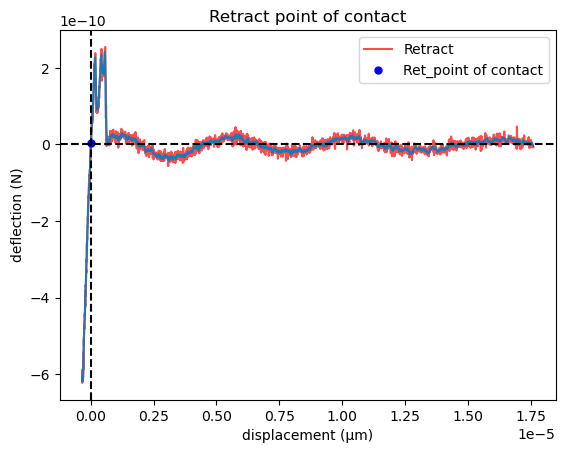

In [ ]:
plt.plot(ret_corrected_displacement, tilt_ret_deflection_N, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.plot(ret_corrected_displacement, savitz_defl)
plt.plot(0, first_positive_deflection, 'o', color='blue', markersize=5, label='Ret_point of contact')  #

y_lower_limit = tilt_ret_deflection_N.min()*0.15 # show 10 percent from the lowest value
print(y_lower_limit)
# plt.ylim(y_lower_limit ,max_positive_value*1.1)
plt.axhline(y=0, color='k', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--')
plt.ylabel('deflection (N)')
plt.xlabel('displacement (µm)')
plt.title('Retract point of contact')
plt.legend()

### Now to find the peaks

x=ret_corrected_dispplacement

y=savitz_defl,

### Filter the deflection with Savitsky 

### Plot plateaus functions
 

In [ ]:
import random
def generate_random_colors(n, alpha=0.3):
    """
    Generate n random rgba color strings for plotly.
    """
    colors = []
    for _ in range(n):
        r = random.randint(0, 255)
        g = random.randint(0, 255)
        b = random.randint(0, 255)
        colors.append(f'rgba({r},{g},{b},{alpha})')
    return colors

def plot_plateaus_with_plotly(x, y, plateaus, colors=None):
    """
    Debug plot plateaus along x axis using plotly.

    Args:
        x (np.ndarray): x-axis data
        y (np.ndarray): y-axis data
        plateaus (list of tuples): List of (start_idx, end_idx) for plateaus
        colors (list): List of color strings for plotly

    Returns:
        None (shows plotly figure)
    """
    import plotly.graph_objs as go

    if colors is None:
        colors = generate_random_colors(len(plateaus))

    plateau_shapes = []
    for i, (start, end) in enumerate(plateaus):
        plateau_shapes.append(
            dict(
                type="rect",
                xref="x", yref="paper",
                x0=x[start], x1=x[end-1],
                y0=0, y1=1,
                fillcolor=colors[i % len(colors)],
                line=dict(width=0),
                layer="below"
            )
        )
    avg_traces = []
    for i, (start, end) in enumerate(plateaus):
        plateau_avg = np.mean(y[start:end])
        avg_traces.append(go.Scatter(
            x=[x[start], x[end-1]],
            y=[plateau_avg, plateau_avg],
            mode='lines',
            line=dict(color=colors[i % len(colors)].replace('0.3', '1.0'), width=2, dash='dash'),
            name=f'Avg Pl {i}: {plateau_avg:.2f}'
        ))

    trace = go.Scatter(x=x, y=y, mode='lines', name='Signal')
    layout = go.Layout(
        title='Detected Plateaus in y along x',
        xaxis=dict(title='x'),
        yaxis=dict(title='y'),
        shapes=plateau_shapes,
        showlegend=True
    )
    fig = go.Figure(data=[trace] + avg_traces, layout=layout)

    # Add invisible traces for legend
    for i, (start, end) in enumerate(plateaus):
        plateau_avg = np.mean(y[start:end])
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(color=colors[i % len(colors)]),
            name=f'Pl {i}: {x[end-1]-x[start]:0.1f} x, avg={plateau_avg:.2f}'
        ))

    fig.show()


### find plateaus

In [ ]:


def find_plateaus(x , y, params=None, dt = 1e-3):
    """
    Identify plateaus in 1D data where the first derivative is close to 0.

    Parameters:
        y (array): 1D signal (e.g., deflection).
        params (dict, optional): Dictionary of parameters to override defaults:
            - 'sav_window_length' (int): Window length for Savitzky-Golay smoothing.
            - 'sav_polyorder' (int): Polynomial order for Savitzky-Golay filter.
            - 'pl_threshold' (float): Max allowed slope (abs(dy/dx)) for plateau detection.
            - 'pl_min_width' (int): Minimum length (in points) of a plateau.
            - 'last_num_plateaus' (int): Number of plateaus to keep from the end.
        dt (float, optional): Spacing between x-values. Default is 1e-3.

    Returns:
        plateaus (list of tuples): List of (start_idx, end_idx) for each detected plateau.
        df_plat (pd.DataFrame): DataFrame with plateau statistics (average, delta, indices, etc.).

    Steps:
        1. Set default and user parameters for smoothing and plateau detection.
        2. Compute the derivative of y with respect to x.
        3. Smooth the derivative using Savitzky-Golay filtering.
        4. Identify regions where the smoothed derivative is below a threshold (potential plateaus).
        5. Filter plateaus by minimum width and keep only the last N plateaus if specified.
        6. For each plateau, calculate statistics such as average value, index of average, and mean derivative.
        7. Compute the difference (delta) between consecutive plateau averages.
        8. Store all plateau statistics in a pandas DataFrame.
        9. Optionally, plot the results for debugging and visualization.
    """

    # Define default parameters
    default_params = {

        'sav_window_length': 10,
        'sav_polyorder': 1,

        'pl_threshold': 0.01,
        'pl_min_width': 20,

        'last_num_plateaus': 5,  # Number of plateaus to ignore at the end
    }
    
    # Merge with input params (input params override defaults)
    if params is None:
        params = {}
    
    final_params = {**default_params, **params}

    # Calculate spacing for time array
    dt_arr = np.arange(len(y)) * dt

    # calculate dx of displacement
    dx =np.abs(x[-1] - x[-2])
    if dx == 0:
        #shift to the left 
        dx = np.abs(x[-2] - x[-3])


    # Calculate velocity from displacement vs time
    velocity = - (calculate_velocity(x, dt_arr)) * 1e-06  # convert to m/s

    print (f'velocity: {velocity:.5f} m/s, dt: {dt:.5f} sec')

    # Calculate derivative of the signal, smooth it, and apply Savitzky-Golay filter
    dy = np.gradient(y, dt * velocity)
    dy_smooth = np.abs(dy)
    dy_smooth_sav = savitzky_golay_smooth(
            dy_smooth,
            window_length=final_params['sav_window_length'], 
            polyorder=final_params['sav_polyorder']
            )

    x = np.arange(len(y)) * dt  # Create x-axis based on dt
    # Debug Plot processed signals
    plt.plot(x, dy, label='dy')
    plt.plot(x, dy_smooth, label='dy_smooth')
    plt.plot(x, dy_smooth_sav, label='dy_smooth_sav')
    plt.axhline(final_params['pl_threshold'], color='r', linestyle='--', label='pl_threshold')
    plt.title('Segment: dy/dx vs x')
    plt.xlabel('x')
    plt.legend()
    plt.show()

    print(final_params['pl_threshold'])

    #n Find flat plateaus in Savitzky-Golay smoothed signal
    is_flat = dy_smooth_sav < final_params['pl_threshold']
    plateaus = []
    start = None
    for i, flat in enumerate(is_flat):
        if flat and start is None:
            start = i
        elif not flat and start is not None:
            if i - start >= final_params['pl_min_width']:
                plateaus.append((start, i))
            start = None
    if start is not None and len(y) - start >= final_params['pl_min_width']:
        plateaus.append((start, len(y)))

    # Define how many plateaus to show starting from the end
    plateaus = plateaus[-final_params['last_num_plateaus']:]

    plateau_avg_idx_arr = []
    # Get the average of each plateau and index of this mean average
    for i, (start, end) in enumerate(plateaus):
        plateau_avg = np.mean(y[start:end])
        # Find the index of the value in y[start:end] closest to plateau_avg
        plateau_avg_idx = start + np.argmin(np.abs(y[start:end] - plateau_avg))
        if i == len(plateaus) - 1:
            plateau_avg_idx_arr.append(start - 1)  # Use start-1 for the last plateau
            print(f'Plateau {i} (last): start={start}, end={end}, average={plateau_avg:.2e}, avg_idx={plateau_avg_idx}')
        else:
            plateau_avg_idx_arr.append(plateau_avg_idx)
            print(f'Plateau {i}: start={start}, end={end}, average={plateau_avg:.2e}, avg_idx={plateau_avg_idx}')    
    
    plateau_delta_avg_arr = []
    # Get the delta of each average of plateau 
    for i, (start, end) in enumerate(plateaus):
        if i > 0:
            prev_avg = np.mean(y[plateaus[i-1][0]:plateaus[i-1][1]])
            # delta_avg = plateau_avg - prev_avg
            print(f'Plateau {i}: delta from previous Y_avg={prev_avg:.2e}')
            plateau_delta_avg_arr.append(prev_avg)
        else:
            # For the first plateau (i == 0), subtract the last plateau average from the first
            last_avg = np.mean(y[plateaus[-1][0]:plateaus[-1][1]])
            first_avg = np.mean(y[start:end])
            delta_first_last = first_avg - last_avg
            # print(f'Plateau {i}: delta from last plateau Y_avg={last_avg:.2e}')
            print(f'Plateau {i}: delta from starting 0 = {delta_first_last:.2e}')
            plateau_delta_avg_arr.append(first_avg)

    # Get the dt of the segment from 0 to the end of the plateau
    for i, (start, end), plateau_avg_idx in zip(range(len(plateaus)), plateaus, plateau_avg_idx_arr):
        delta_time = plateau_avg_idx * dt
        print(f'Plateau {i}: delta time from 0 to avg plat={delta_time:.2e} sec, Y_avg={y[plateau_avg_idx]:.2e}')     


    # create dataframe of plateaus, plateaus_avg, and delta_avg, include plateau index and plateaus
    # shortened functions are done in dataframe, longer are above for debugging


    # Calculate the mean of the derivative of each plateau from dy
    plateau_derivatives = []
    for start, end in plateaus:
        plateau_derivative = np.mean(np.abs(dy_smooth_sav[start:end]))
        plateau_derivatives.append(plateau_derivative)
        print(f'Plateau {len(plateaus)}: dy/dx avg={plateau_derivative:.2e}')


    df_plat = pd.DataFrame({
        'plateaus': [i for i, _ in enumerate(plateaus)],
        'plateau_avg': [np.mean(y[start:end]) for start, end in plateaus],
        'delta_avg': plateau_delta_avg_arr,
        'start': [start for start, _ in plateaus],
        'end': [end for _, end in plateaus],
        'plateau_avg_idx': plateau_avg_idx_arr,
        'delta_time': [plateau_avg_idx * dt for plateau_avg_idx in plateau_avg_idx_arr],
        'mean dy/dx': plateau_derivatives,
        'plateau_std.dev': [np.std(y[start:end]) for start, end in plateaus],
        'plateau_MSE': [np.mean((y[start:end] - np.mean(y[start:end]))**2) for start, end in plateaus]
    })

    ### Debug plot plateaus along x axis using plotly

    plateau_shapes = []
    colors = ['rgba(31,119,180,0.3)', 'rgba(255,127,14,0.3)', 'rgba(44,160,44,0.3)', 
              'rgba(214,39,40,0.3)', 'rgba(148,103,189,0.3)', 'rgba(140,86,75,0.3)', 
              'rgba(227,119,194,0.3)', 'rgba(127,127,127,0.3)', 'rgba(188,189,34,0.3)', 
              'rgba(23,190,207,0.3)']

    avg_traces = []
    for i, (start, end) in enumerate(plateaus):
        plateau_shapes.append(
            dict(
                type="rect",
                xref="x", yref="paper",
                x0=x[start], x1=x[end-1],
                y0=0, y1=1,
                fillcolor=colors[i % len(colors)],
                line=dict(width=0),
                layer="below"
            )
        )
        # Plot the average as a horizontal line
        plateau_avg = np.mean(y[start:end])
        avg_traces.append(go.Scatter(
            x=[x[start], x[end-1]],
            y=[plateau_avg, plateau_avg],
            mode='lines',
            line=dict(color=colors[i % len(colors)].replace('0.3', '1.0'), width=2, dash='dash'),
            name=f'Avg Pl {i}: {plateau_avg:.2g}'
        ))

        # Plot the delta between this and previous average as a vertical line
        if i > 0:
            prev_start, prev_end = plateaus[i-1]
            prev_avg = np.mean(y[prev_start:prev_end])
            delta_x = x[start]
            avg_traces.append(go.Scatter(
            x=[delta_x, delta_x],
            y=[prev_avg, plateau_avg],
            mode='lines',
            line=dict(color='black', width=1, dash='dot'),
            name=f'Delta {i-1}-{i}: {plateau_avg - prev_avg:.2g}'
            ))

    trace = go.Scatter(x=x, y=y, mode='lines', name='Signal')
    layout = go.Layout(
        title='Detected Plateaus in y along x',
        xaxis=dict(title='x'),
        yaxis=dict(title='y'),
        shapes=plateau_shapes,
        showlegend=True
    )
    fig = go.Figure(data=[trace] + avg_traces, layout=layout)
    fig.show()

    # Return values for plotting and list of plateaus
    
    return plateaus, df_plat

### Define params for plateau finder

In [ ]:
# plt.plot(rel_time, defl_savitz)
# plt.show()

## run plateau analysis

velocity: 0.00061 m/s, dt: 0.00002 sec


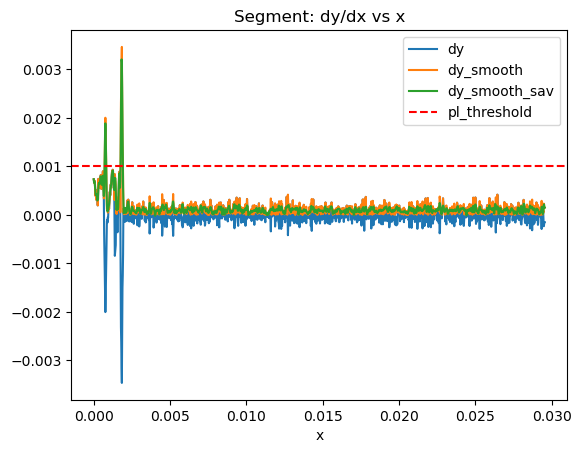

0.001
Plateau 0: start=0, end=36, average=1.06e-10, avg_idx=19
Plateau 1: start=41, end=88, average=1.65e-10, avg_idx=60
Plateau 2 (last): start=96, end=1478, average=-2.03e-12, avg_idx=472
Plateau 0: delta from starting 0 = 1.08e-10
Plateau 1: delta from previous Y_avg=1.06e-10
Plateau 2: delta from previous Y_avg=1.65e-10
Plateau 0: delta time from 0 to avg plat=3.80e-04 sec, Y_avg=1.07e-10
Plateau 1: delta time from 0 to avg plat=1.20e-03 sec, Y_avg=1.64e-10
Plateau 2: delta time from 0 to avg plat=1.90e-03 sec, Y_avg=2.69e-11
Plateau 3: dy/dx avg=5.89e-04
Plateau 3: dy/dx avg=4.82e-04
Plateau 3: dy/dx avg=1.01e-04


In [ ]:
# Find plateaus after the contact point and do a double savitszky-golay smoothing
defl_savitz = savitz_defl[index_first_positive:]
displacement = ret_corrected_displacement[index_first_positive:]

# Usage with real data
params = {## time
    'sav_window_length': 24,
    'sav_polyorder': 11,

    'pl_threshold_old': 0.3e-6,
    'pl_threshold': 0.1e-2 ,
    'pl_min_width': 1,
    'last_num_plateaus': 7,  # Number of plateaus to ignore at the end
}



rel_time = np.arange(len(displacement)) * relative_SR_ret  # Assuming a constant time step

# For relative time, you modified find plateaus to get the relative SR of Retract, which is the 2nd index
plateaus, df_plat = find_plateaus(displacement, defl_savitz, params, dt= relative_SR_ret)
# plateaus, df_plat = find_plateaus(defl_savitz, params, dt=1)
# print(f'rel_sr_ret: {relative_SR_ret}')


Plateau finder works by:
1. Define the smoothing parameter for `uniform_filter1d`, which will smooth the derivative of y (controlled by `dy_smooth`).
2. Apply Savitzky-Golay smoothing to dy/dx : `sav_window_length` defines the length of the window, and `sav_polyorder` sets the polynomial order. These are set in the `params` dictionary (e.g., `sav_window_length = 10`, `sav_polyorder = 1`).
3. Set the `pl_threshold` to define which peaks (in green), will be taken into the selection of "rupture/unfolding/untethering" events.
Set the plateau minimum width with `pl_min_width`, in terms of the x input's units

In [ ]:
import plotly.graph_objects as go

# Prepare the figure
fig = go.Figure()

showDisplacementonX = False # False, will show time on x axis, else meters

if showDisplacementonX:
    rel_time = displacement


# 1. Add main signal trace (Savitzky-Golay smoothed)
fig.add_trace(go.Scatter(
    x=rel_time, y=defl_savitz,
    mode='lines',
    name='Savitzky-Golay Smoothed Deflection'
))

# 2. Add plateau markers with detailed hover info
for i, idx in enumerate(df_plat['plateau_avg_idx']):
    fig.add_trace(go.Scatter(
        x=[rel_time[idx]],
        y=[defl_savitz[idx]],
        mode='markers',
        marker=dict(size=10),
        name=f'Plateau {i}',
        hovertemplate=(
            f'Plat {i}<br>'
            f'Yavg = {df_plat["plateau_avg"].iloc[i]:.2e}<br>'
            f'ΔYavg = {df_plat["delta_avg"].iloc[i]:.2e}<br>'
            f'Δt = {df_plat["delta_time"].iloc[i]:.2e} s<br>'
            f'x̄(dy/dx) = {df_plat["mean dy/dx"].iloc[i]:.2e}<br>'
            f'MSE = {df_plat["plateau_MSE"].iloc[i]:.2e}<br>'
            '<extra></extra>'
        )
    ))

# 3. Overlay plateau rectangles + average and delta lines
colors = ['rgba(31,119,180,0.3)', 'rgba(255,127,14,0.3)', 'rgba(44,160,44,0.3)', 
          'rgba(214,39,40,0.3)', 'rgba(148,103,189,0.3)', 'rgba(140,86,75,0.3)', 
          'rgba(227,119,194,0.3)', 'rgba(127,127,127,0.3)', 'rgba(188,189,34,0.3)', 
          'rgba(23,190,207,0.3)']

shapes = []
for i, (start, end) in enumerate(plateaus):
    # Shaded rectangle
    shapes.append(
        dict(
            type="rect",
            xref="x", yref="paper",
            x0=rel_time[start], x1=rel_time[end-1],
            y0=0, y1=1,
            fillcolor=colors[i % len(colors)],
            line=dict(width=0),
            layer="below"
        )
    )

    # Horizontal average line
    plateau_avg = np.mean(defl_savitz[start:end])
    fig.add_trace(go.Scatter(
        x=[rel_time[start], rel_time[end-1]],
        y=[plateau_avg, plateau_avg],
        mode='lines',
        line=dict(color=colors[i % len(colors)].replace('0.3', '1.0'), width=2, dash='dash'),
        name=f'Avg Pl {i}: {plateau_avg:.2g}'
    ))

    # Vertical delta line from previous plateau
    if i > 0:
        prev_start, prev_end = plateaus[i-1]
        prev_avg = np.mean(defl_savitz[prev_start:prev_end])
        delta_x = rel_time[start]
        fig.add_trace(go.Scatter(
            x=[delta_x, delta_x],
            y=[prev_avg, plateau_avg],
            mode='lines',
            line=dict(color='black', width=1, dash='dot'),
            name=f'Δ {i-1}-{i}: {plateau_avg - prev_avg:.2g}'
        ))

if showDisplacementonX:
    xaxis_title = 'Displacement (m)'
else:
    xaxis_title = 'Time (s)'

# 4. Final layout
fig.update_layout(
    title='Detected Plateaus with Averages and Δ',
    xaxis_title=xaxis_title,
    yaxis_title='Deflection (N)',
    legend_title='Legend',
    shapes=shapes,
    showlegend=True
)

fig.show()

In [ ]:
# Save as interactive HTML
saveFile = True
if saveFile:
    # Define the path and name for saving the figure
    path= '/Users/evillz/Data/article/tether_figs/'
    name = 'plateau_analysis_vs_timev2_devam'
    fig.write_html(path+name+'.html', full_html=True, include_plotlyjs="include")

In [ ]:
def create_plateau_png(rel_time, defl_savitz, plateaus, df_plat, 
                       output_path='plateau_analysis.png', 
                       showDisplacementonX=False, 
                       title='Detected Plateaus with Averages and Δ',
                       width=1200, height=800):
    """
    Create and save a PNG file of the plateau analysis graph.
    
    Parameters:
        rel_time (array): Time or displacement array
        defl_savitz (array): Savitzky-Golay smoothed deflection data
        plateaus (list): List of (start, end) tuples for plateau regions
        df_plat (DataFrame): DataFrame with plateau analysis results
        output_path (str): Path where to save the PNG file
        showDisplacementonX (bool): If True, shows displacement on x-axis, else time
        title (str): Title for the plot
        width (int): Width of the image in pixels
        height (int): Height of the image in pixels
    
    Returns:
        str: Path to the saved PNG file
    """
    import plotly.graph_objects as go
    import os
    
    # Prepare the figure
    fig = go.Figure()

    # Use displacement if requested
    if showDisplacementonX:
        x_data = displacement  # You'll need to pass this as a parameter if needed
    else:
        x_data = rel_time

    # 1. Add main signal trace (Savitzky-Golay smoothed)
    fig.add_trace(go.Scatter(
        x=x_data, y=defl_savitz,
        mode='lines',
        name='Savitzky-Golay Smoothed Deflection',
        line=dict(color='blue', width=2)
    ))

    # 2. Add plateau markers with detailed hover info
    for i, idx in enumerate(df_plat['plateau_avg_idx']):
        fig.add_trace(go.Scatter(
            x=[x_data[idx]],
            y=[defl_savitz[idx]],
            mode='markers',
            marker=dict(size=10, color=f'rgba({31+i*40},{119+i*30},{180+i*20},1.0)'),
            name=f'Plateau {i}',
            hovertemplate=(
                f'Plat {i}<br>'
                f'Yavg = {df_plat["plateau_avg"].iloc[i]:.2e}<br>'
                f'ΔYavg = {df_plat["delta_avg"].iloc[i]:.2e}<br>'
                f'Δt = {df_plat["delta_time"].iloc[i]:.2e} s<br>'
                f'x̄(dy/dx) = {df_plat["mean dy/dx"].iloc[i]:.2e}<br>'
                '<extra></extra>'
            )
        ))

    # 3. Overlay plateau rectangles + average and delta lines
    colors = ['rgba(31,119,180,0.3)', 'rgba(255,127,14,0.3)', 'rgba(44,160,44,0.3)', 
              'rgba(214,39,40,0.3)', 'rgba(148,103,189,0.3)', 'rgba(140,86,75,0.3)', 
              'rgba(227,119,194,0.3)', 'rgba(127,127,127,0.3)', 'rgba(188,189,34,0.3)', 
              'rgba(23,190,207,0.3)']

    shapes = []
    for i, (start, end) in enumerate(plateaus):
        # Shaded rectangle
        shapes.append(
            dict(
                type="rect",
                xref="x", yref="paper",
                x0=x_data[start], x1=x_data[end-1],
                y0=0, y1=1,
                fillcolor=colors[i % len(colors)],
                line=dict(width=0),
                layer="below"
            )
        )

        # Horizontal average line
        plateau_avg = np.mean(defl_savitz[start:end])
        fig.add_trace(go.Scatter(
            x=[x_data[start], x_data[end-1]],
            y=[plateau_avg, plateau_avg],
            mode='lines',
            line=dict(color=colors[i % len(colors)].replace('0.3', '1.0'), width=3, dash='dash'),
            name=f'Avg Pl {i}: {plateau_avg:.2g}',
            showlegend=False  # Don't clutter legend with these
        ))

        # Vertical delta line from previous plateau
        if i > 0:
            prev_start, prev_end = plateaus[i-1]
            prev_avg = np.mean(defl_savitz[prev_start:prev_end])
            delta_x = x_data[start]
            fig.add_trace(go.Scatter(
                x=[delta_x, delta_x],
                y=[prev_avg, plateau_avg],
                mode='lines',
                line=dict(color='black', width=2, dash='dot'),
                name=f'Δ {i-1}-{i}: {plateau_avg - prev_avg:.2g}',
                showlegend=False  # Don't clutter legend with these
            ))

    # Set axis titles
    if showDisplacementonX:
        xaxis_title = 'Displacement (m)'
    else:
        xaxis_title = 'Time (s)'

    # 4. Final layout with enhanced styling for PNG export
    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            font=dict(size=20, color='black')
        ),
        xaxis=dict(
            title=dict(text=xaxis_title, font=dict(size=16)),
            tickfont=dict(size=14),
            gridcolor='lightgray',
            showgrid=True
        ),
        yaxis=dict(
            title=dict(text='Deflection (N)', font=dict(size=16)),
            tickfont=dict(size=14),
            gridcolor='lightgray',
            showgrid=True
        ),
        legend=dict(
            font=dict(size=12),
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='black',
            borderwidth=1
        ),
        shapes=shapes,
        showlegend=True,
        plot_bgcolor='white',
        paper_bgcolor='white',
        width=width,
        height=height
    )

    # Save as PNG
    try:
        fig.write_image(output_path, format='png', engine='kaleido')
        print(f"✅ PNG saved successfully: {output_path}")
        print(f"📊 File size: {os.path.getsize(output_path)} bytes")
        return output_path
    except Exception as e:
        print(f"❌ Error saving PNG: {e}")
        print("💡 Make sure you have kaleido installed: pip install kaleido")
        return None

# Example usage function
def save_current_analysis_as_png(filename='plateau_analysis.png'):
    """
    Save the current plateau analysis as a PNG file using the data from the notebook.
    This function uses the global variables from the notebook analysis.
    """
    if 'plateaus' in globals() and 'df_plat' in globals():
        output_path = create_plateau_png(
            rel_time=rel_time,
            defl_savitz=defl_savitz, 
            plateaus=plateaus,
            df_plat=df_plat,
            output_path=filename,
            showDisplacementonX=False,
            title=f'Plateau Analysis - {os.path.basename(filename)}',
            width=1400,
            height=900
        )
        return output_path
    else:
        print("❌ No plateau analysis data found. Run the analysis first!")
        return None

In [ ]:
# Example: Create PNG files of your plateau analysis
# Make sure you have run the plateau analysis first (cells above)
makePng = False  # Set to True to create PNG files
# Method 1: Use the simple function with current data
png_file = save_current_analysis_as_png('my_plateau_analysis.png')

if makePng: 
    # Method 2: Use the full function with custom parameters
    if 'plateaus' in locals() and 'df_plat' in locals():
        custom_png = create_plateau_png(
            rel_time=rel_time,
            defl_savitz=defl_savitz, 
            plateaus=plateaus,
            df_plat=df_plat,
            output_path='/Users/evillz/Data/article/tether_figs/custom_plateau.png',
            showDisplacementonX=False,  # Set to True for displacement on x-axis
            title='Custom Plateau Analysis',
            width=1600,
            height=1000
        )

    # Method 3: Create multiple versions
    versions = [
        ('time_analysis.png', False, 'Plateau Analysis vs Time'),
        ('displacement_analysis.png', True, 'Plateau Analysis vs Displacement')
    ]

    for filename, show_disp, title in versions:
        create_plateau_png(
            rel_time=rel_time if not show_disp else displacement,
            defl_savitz=defl_savitz, 
            plateaus=plateaus,
            df_plat=df_plat,
            output_path=filename,
            showDisplacementonX=show_disp,
            title=title,
            width=1200,
            height=800
        )

/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_66861/2128313560.py:148: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




✅ PNG saved successfully: my_plateau_analysis.png
📊 File size: 59473 bytes


In [ ]:
import xarray as xr

# save all